# Congestion Revenue Allocation on the WSCC 9-Bus Network

**Companion to _Market Seams in the Western Interconnection_ (Dockery, 2026).**

This notebook reuses the unified WSCC / IEEE 9-bus clearing from the seams
examples, then partitions the network into **two balancing authorities (BAs)**
joined by two tie lines, to study **how congestion revenue should be allocated**
when one BA's internal constraint separates prices in the other.

| Section | What you see |
|---|---|
| **0-2. Shared network, shift factors, unified clearing** | DC power flow, nodal LMPs $\lambda_n$, and the per-line congestion-rent decomposition $\sum_l |\mu_l|\bar F_l$ |
| **3. Two balancing authorities** | The BA partition, the two interconnectors, and the congestion-revenue ledger |
| **3A. Tie congested** | Rent collected directly on an interconnector |
| **3B. Internal constraint, external separation** | One BA's *internal* limit separates prices in the *other* BA across the seam |
| **Allocation** | **Method 1** (home BA keeps it) vs **Method 2** (rebate cross-seam separation), side by side |
| **Unified vs independent** | Whether the cross-seam rent survives independent (uncoordinated) operation |

All computation reuses [`seams_engine.py`](seams_engine.py); the allocation
methodology is defined inline below so it can be tuned. Sections 0-2 are reused
from [`seams_examples.ipynb`](seams_examples.ipynb), with one addition to the
fleet: an \$80 *pocket peaker* at bus 5 (dear enough that it never clears in the
unified runs, so those results are unchanged — it only matters for BA-2's
independent counterfactual in Section 3).

## 0. Setup

In [ ]:
#@title ▶ Run me first — Colab setup (installs packages, fetches the helper modules)
# On Google Colab this installs the few non-default packages and downloads the
# three helper modules next to the notebook. Running locally it does nothing
# (the modules are already on disk), so the same notebook works in both places.
import sys, subprocess

def _sh(cmd):
    print("$", cmd)
    subprocess.run(cmd, shell=True, check=True)

if "google.colab" in sys.modules:
    _sh("pip install -q pypsa pandapower pycirclize")
    _base = "https://raw.githubusercontent.com/pdockery/wscc9-illustrative-model/main"
    for _f in ("ieee9_network.py", "seams_engine.py", "nodal_plot.py"):
        _sh(f"wget -q {_base}/{_f} -O {_f}")
    print("Colab setup complete.")
else:
    print("Local run: using the modules already in this folder.")


In [1]:
import sys, os, importlib
import warnings; warnings.filterwarnings('ignore')
import logging; logging.getLogger('pypsa').setLevel(logging.ERROR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('.'))

from ieee9_network import build_ieee9_network
import seams_engine, nodal_plot
importlib.reload(seams_engine); importlib.reload(nodal_plot)
from seams_engine import (
    compute_ptdf, MarketEngine, solve_engine_dispatch,
    physical_flows, seam_dual_gap, to_supply_demand, susceptance_widths,
)
from nodal_plot import (
    plot_network_topology, plot_nodal_circlize,
    assign_bus_colors, BUS_PALETTE, TRANSIT_COLOR,
)
pd.set_option('display.width', 160)
print('ready')

ready

### Master fleet & load tables

The 9-bus system has four generators (a \$20 baseload, a \$35 and a \$50 unit, and
an \$80 *pocket peaker* sited at the bus-5 load) and three loads. These are the
physical primitives; the *market* partition (which bus belongs to which engine /
balancing authority) is chosen later and independently. The \$80 peaker is dear
enough that it never clears in the unified runs below — it only matters when bus 5
is isolated behind its own constraint (Section 3's independent counterfactual).

```
        (1)gen $20            (3)gen $50
          |                     |
         [4]---[5]load+$80pk---[6]---[7]load
          |                     |
         [9]load---[8]---------/
                    |
                  (2)gen $35
```
Lines (rating MW): `0:1-4(250) 1:4-5(250) 2:5-6(150) 3:3-6(300) 4:6-7(150) 5:7-8(250) 6:8-2(250) 7:8-9(250) 8:9-4(250)`

In [2]:
# Physical primitives -- the resource stack and loads on the shared network
GEN_FLEET = {
    'gen_slack_0': {'bus': '1', 'cost': 20.0, 'p_nom': 250.0},   # cheap baseload (BA-2)
    'gen_0':       {'bus': '2', 'cost': 35.0, 'p_nom': 300.0},   # mid-merit  (BA-1)
    'gen_1':       {'bus': '3', 'cost': 50.0, 'p_nom': 270.0},   # peaker     (BA-1)
    'peak_b5':     {'bus': '5', 'cost': 80.0, 'p_nom': 40.0},   # BA-2 pocket peaker at the bus-5 load
}
LOADS = {'5': 90.0, '7': 100.0, '9': 125.0}

# Circlize sector order: clockwise from 12 o'clock, following the network ring
# so the chord diagram reads in the same spatial order as the topology diagram.
RING_ORDER = ['3', '6', '7', '8', '2', '9', '4', '1', '5']

# Orientation, applied to ALL node + circlize plots so they read alike:
#  - node diagram rotated 180deg  -> bus 3 at the bottom, bus 2 NW, bus 9 at top;
#  - circlize centred on bus 9    -> bus 9 across 12 o'clock, bus 3 near the bottom.
ROTATION_DEG = 180
CENTER_BUS = '9'
COORDS = nodal_plot.rotate_coords(nodal_plot.IEEE9_COORDS, ROTATION_DEG)

def build_network(line_ratings=None):
    # Build the 9-bus PyPSA network, applying any line-rating overrides.
    n = build_ieee9_network(periods=1)
    for ln, mw in (line_ratings or {}).items():
        n.lines.loc[ln, 's_nom'] = float(mw)
    return n

def make_engine(name, buses, activated='all'):
    # Assign every fleet gen and load whose bus is in `buses` to this engine.
    buses = {str(b) for b in buses}
    gens = {g: dict(s) for g, s in GEN_FLEET.items() if str(s['bus']) in buses}
    loads = {b: mw for b, mw in LOADS.items() if b in buses}
    return MarketEngine(name=name, gens=gens, loads=loads, activated_lines=activated)

print('fleet:', {g: (s['bus'], s['cost'], s['p_nom']) for g, s in GEN_FLEET.items()})
print('loads:', LOADS)
print('ring order:', RING_ORDER, '| rotation', ROTATION_DEG, 'deg | centre bus', CENTER_BUS)

fleet:

{'gen_slack_0': ('1', 20.0, 250.0), 'gen_0': ('2', 35.0, 300.0), 'gen_1': ('3', 50.0, 270.0), 'peak_b5': ('5', 80.0, 40.0)}

loads:

{'5': 90.0, '7': 100.0, '9': 125.0}

ring order:

['3', '6', '7', '8', '2', '9', '4', '1', '5']

| rotation

180

deg | centre bus

9

## 1. Shared network & shift factors  (§2.1)

> *A net injection of $p$ MW at bus $n$ produces an incremental flow of
> $SF_{n,m}\,p$ on constraint $m$.*

The shift-factor (PTDF) matrix is a primitive of the **physics**, shared by every
engine. Everything downstream — each engine's flow $F^M_m=\sum_n SF_{n,m}\,p^{\text{inj},M}_n$
and the LMP congestion term $\sum_m SF_{n,m}\mu_m$ — is built from this one matrix.

In [3]:
pt = compute_ptdf(build_network(), slack_bus='1')
SF = pd.DataFrame(pt.ptdf,
                  index=[f'{l} ({a}-{b})' for l, (a, b) in zip(pt.lines, pt.line_buses)],
                  columns=[f'bus {b}' for b in pt.buses]).round(3)
print('Shift-factor matrix  SF[line, bus]   (slack = bus 1, so its column is 0 by definition)')
SF


# Canonical per-bus colours: assigned ONCE from the full fleet (which buses host
# gen/load), so every figure -- unified, scenario, or independent per-BA -- uses
# the SAME colour for a given bus. A subset clearing (e.g. one BA alone) no longer
# restarts the palette and reshuffles colours.
_sup_full = {}
for _g, _s in GEN_FLEET.items():
    _sup_full.setdefault(_s['bus'], []).append(_s)
BUS_COLORS = assign_bus_colors(pt.buses, _sup_full, LOADS)


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


Shift-factor matrix  SF[line, bus]   (slack = bus 1, so its column is 0 by definition)

### Line "slipperiness" — the reactance map

The WSCC 9-bus assigns a distinct reactance $x_m$ to every line. For DC flow the
power a line carries per unit of angle difference across it is its **susceptance**
$b_m = 1/x_m$ — a low-reactance line is *slippery* and soaks up a disproportionate
share of any transfer, all else equal. The cell below draws each line with a width
proportional to $b_m$ (wider = lower $x$ = more slippery), giving a physical
picture of *where power prefers to flow* before any dispatch is chosen. Width is an
**orthogonal channel** to the congestion colour used later: width = slipperiness,
red = binding.

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


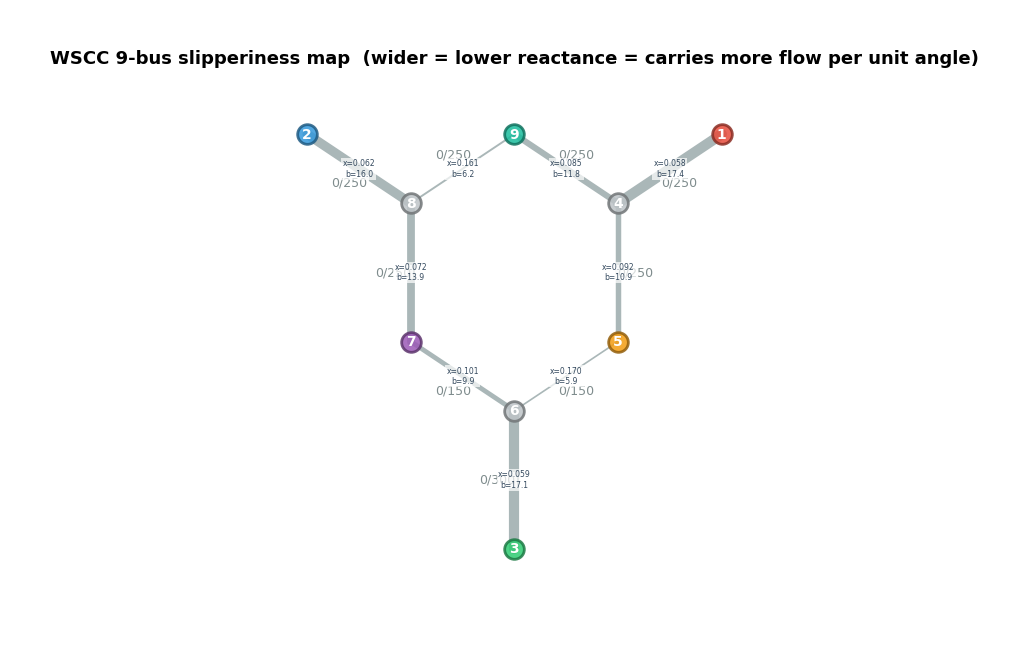

,x (reactance),b = 1/x,draw width
line_0 (1-4),0.0576,17.36,7.50
line_3 (3-6),0.0586,17.06,7.34
line_6 (8-2),0.0625,16.00,6.75
line_5 (7-8),0.0720,13.89,5.59
line_8 (9-4),0.0850,11.76,4.43
line_1 (4-5),0.0920,10.87,3.94
line_4 (6-7),0.1008,9.92,3.42
line_7 (8-9),0.1610,6.21,1.38
line_2 (5-6),0.1700,5.88,1.20


In [4]:
pt = compute_ptdf(build_network(), slack_bus='1')
widths = susceptance_widths(pt, wmin=1.2, wmax=7.5)   # {line: linewidth} from b = 1/x

# Colour the nodes with the SAME per-bus palette used throughout the notebook:
# gen/load buses take their palette colour, pure transit buses stay grey. The
# membership comes from the fleet (not the dispatch), so these node colours match
# the dispatched figures exactly -- this is purely a reactance map, no flows.
node_colors = BUS_COLORS   # canonical per-bus palette (defined with pt above)

# Pure reactance map: no dispatch annotations, no flows -- width encodes
# slipperiness only, nodes carry the standard palette colour.
fig, ax = plot_network_topology(
    build_network(), supply_by_bus={}, demand_by_bus={},
    bus_colors=node_colors, bus_coords=COORDS,
    line_flows={l: 0.0 for l in pt.lines},   # 0 flow -> no arrows, grey lines
    line_widths=widths,
    title='WSCC 9-bus slipperiness map  (wider = lower reactance = carries more flow per unit angle)',
)
# annotate each line with its x and b
for l, (b0, b1) in zip(pt.lines, pt.line_buses):
    x0, y0 = COORDS[b0]; x1, y1 = COORDS[b1]
    xm, ym = (x0 + x1) / 2, (y0 + y1) / 2
    b = pt.susceptance[pt.line_idx[l]]
    ax.text(xm, ym, f'x={1/b:.3f}\nb={b:.1f}', fontsize=5.5, ha='center', va='center',
            color='#34495E', bbox=dict(fc='white', ec='none', alpha=0.7, pad=0.8), zorder=6)
plt.show()

pd.DataFrame({
    'x (reactance)': [round(1 / pt.susceptance[pt.line_idx[l]], 4) for l in pt.lines],
    'b = 1/x': [round(pt.susceptance[pt.line_idx[l]], 2) for l in pt.lines],
    'draw width': [round(widths[l], 2) for l in pt.lines],
}, index=[f'{l} ({a}-{b})' for l, (a, b) in zip(pt.lines, pt.line_buses)]).sort_values('b = 1/x', ascending=False)

## 2. One engine — the unified clearing  (§2.7 counterfactual)

A single optimisation over **all** resources, loads, and constraints. This is the
benchmark the seams problem is measured against: one price per bus, every
transmission limit enforced against the true total flow.

**Edit below:** generator costs, load levels, and line ratings. Tightening a line
creates congestion and pulls the LMPs apart — *price separation on the constrained
path*.

In [5]:
# -- EDIT -- unified-clearing inputs --------------------------------------
COST_OVERRIDE   = {}                      # e.g. {'gen_0': 45.0} to re-bid the $35 unit
LOAD_OVERRIDE   = {}                      # e.g. {'7': 130.0}
LINE_RATINGS    = {'line_1': 90.0, 'line_5': 90.0}   # squeeze 4-5 and 7-8 -> congestion
# -------------------------------------------------------------------------

net = build_network(LINE_RATINGS)
pt  = compute_ptdf(net, slack_bus='1')

unified = make_engine('UNIFIED', buses=pt.buses)
for g, c in COST_OVERRIDE.items(): unified.gens[g]['cost'] = c
for b, v in LOAD_OVERRIDE.items(): unified.loads[b] = v

res = solve_engine_dispatch(pt, unified)
print('dispatch (MW):', {k: round(v, 1) for k, v in res.dispatch.items()})
print('energy price :', round(res.energy_price, 2), '$/MWh')
binding = {k: round(v, 1) for k, v in res.line_dual.items() if abs(v) > 1e-3}
print('binding lines:', binding or 'none')
print()
print('LMP by bus ($/MWh):')
pd.Series({b: round(res.lmp[b], 2) for b in pt.buses}).to_frame('LMP').T

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


dispatch (MW):

{'gen_slack_0': 183.2, 'gen_0': 121.8, 'gen_1': 10.0, 'peak_b5': 0.0}

energy price :

20.0

$/MWh

binding lines:

{'line_1': -46.0, 'line_5': 4.5}

LMP by bus ($/MWh):

,1,2,3,4,5,6,7,8,9
LMP,20.0,35.0,50.0,20.0,60.37,50.0,43.85,35.0,25.18


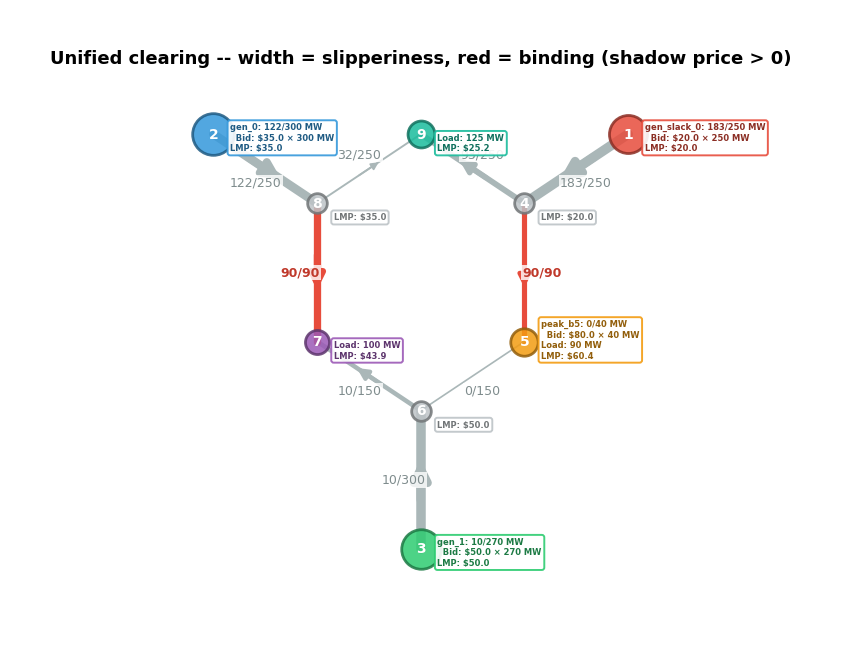

In [6]:
# Topology with DC power flow. Line WIDTH = slipperiness (b=1/x); line COLOUR =
# congestion. A line is red only when its shadow price is non-zero (a genuine
# binding transmission limit) -- NOT merely when flow hits rating, which can
# happen because the generator behind a radial line is maxed out.
sup, dem = to_supply_demand(unified, res)
colors = dict(BUS_COLORS)   # canonical colours; a subset clearing no longer reshuffles them
flows = {l: res.flow_own[l] for l in pt.lines}
binding_lines = {l for l, mu in res.line_dual.items() if abs(mu) > 1e-3}
fig, ax = plot_network_topology(
    net, sup, dem, bus_colors=colors, bus_lmps=res.lmp, line_flows=flows,
    line_widths=susceptance_widths(pt), constrained_lines=binding_lines, bus_coords=COORDS,
    title='Unified clearing -- width = slipperiness, red = binding (shadow price > 0)',
)
plt.show()

### Nodal merit-order + chord view, and the congestion shadow price

The same circlize diagram used in [`inspect_sced_results.ipynb`](inspect_sced_results.ipynb),
built here from the unified DC-OPF. Each sector is a bus: the **left** half is the
merit-order staircase (solid = dispatched, faded = available capacity, dotted line =
marginal cost), the **right** half is the demand bar drawn at **LMP height**, and the
**chords** are PTDF-traced generator→load deliveries. Below the figure we print the
congestion shadow price $\mu_m$ on each binding line — the dual of eq. (5), and the
exact quantity that splits the LMPs through $\sum_m SF_{n,m}\,\mu_m$.

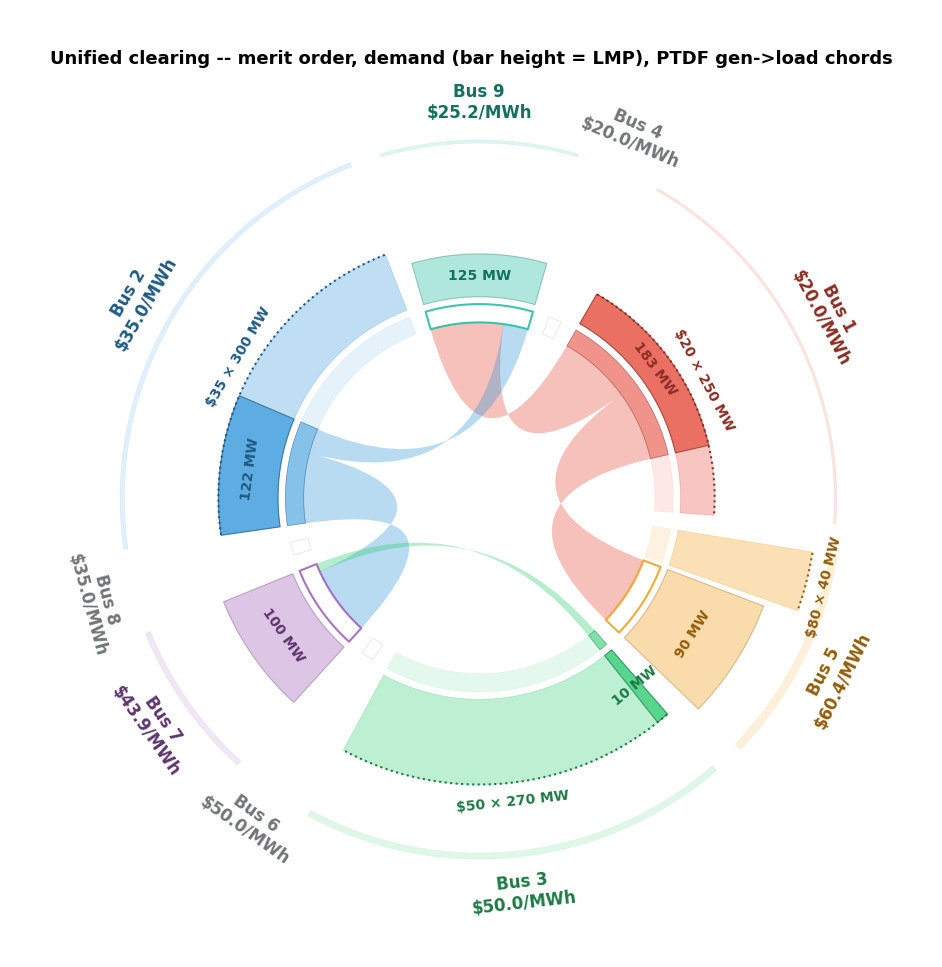

Binding transmission constraints -- congestion shadow price |mu_m| (eq. 5):

  line_1 (4-5): |mu| = $45.98/MWh   (flow +90 MW at the 90 MW limit)

  line_5 (7-8): |mu| = $4.46/MWh   (flow -90 MW at the 90 MW limit)


Settlement by node  (payments to generation vs payments by load):

,LMP ($/MWh),gen (MW),paid to gen ($/h),load (MW),paid by load ($/h)
bus,,,,,
1,20.0,183.2,3664.5,0.0,0.0
2,35.0,121.8,4262.2,0.0,0.0
3,50.0,10.0,500.0,0.0,0.0
4,20.0,0.0,0.0,0.0,0.0
5,60.37,0.0,0.0,90.0,5432.9
6,50.0,0.0,0.0,0.0,0.0
7,43.85,0.0,0.0,100.0,4385.4
8,35.0,0.0,0.0,0.0,0.0
9,25.18,0.0,0.0,125.0,3147.9


...

(equal by the LMP decomposition: the energy component nets to zero because total gen = total load,
 so only the congestion term survives, and it equals mu x flow on each binding line.)


Marginal value of line capacity  (shadow price x flow, per line):

,from,to,flow (MW),rating (MW),binding,|mu| ($/MWh = value of +1 MW),rent |mu| x flow ($/h)
line,,,,,,,
line_0,1,4,183.2,250.0,False,0.0,0.0
line_1,4,5,90.0,90.0,True,45.98,4137.8
line_2,5,6,0.0,150.0,False,0.0,0.0
line_3,3,6,10.0,300.0,False,0.0,0.0
line_4,6,7,10.0,150.0,False,0.0,0.0
line_5,7,8,-90.0,90.0,True,4.46,401.7
line_6,8,2,-121.8,250.0,False,0.0,0.0
line_7,8,9,31.8,250.0,False,0.0,0.0
line_8,9,4,-93.2,250.0,False,0.0,0.0


The |mu| column is the value of relaxing each line by 1 MW; only binding lines carry a positive value.
The rent column decomposes the congestion rent above by line and totals $4,539.5/h.


wrote seams_settlement_by_node.csv  and  seams_line_capacity_value.csv  to  C:\Users\docke\Projects\ASSUME\assume\testbed

In [7]:
# Circlize / chord view of the unified clearing (reuses sup, dem, colors, res from above).
flow_list = nodal_plot.compute_ptdf_flows(net, sup, dem)   # PTDF-traced gen->load chords
gen_mc = {g: spec['cost'] for g, spec in unified.gens.items()}

fig = plot_nodal_circlize(
    sup, dem, pt.buses,
    flows=flow_list,
    clearing_price=res.energy_price,
    bus_lmps=res.lmp,
    bus_colors=colors,
    gen_marginal_costs=gen_mc,
    sector_order=RING_ORDER,   # clockwise from 12 o'clock, following the network ring
    center_bus=CENTER_BUS,     # bus 9 centred at 12 o'clock (matches the rotated node diagram)
    figsize=(8.5, 9.0),        # fills the width of an 8.5x11 page (extra height -> title headroom)
    label_fontsize=12,         # outer sector labels (Bus N / LMP)
    track_fontsize=10,         # in-track bid / dispatch / load-MW labels, >= 10 pt
    show_legend=False,         # per-bus gen/load/LMP already on the ring + in-track; legend was sub-10 pt and duplicative
    title='Unified clearing -- merit order, demand (bar height = LMP), PTDF gen->load chords',
)
plt.show()

# Shadow price of the binding line constraint(s): the congestion dual mu_m (eq. 5).
binding = {l: mu for l, mu in res.line_dual.items() if abs(mu) > 1e-3}
if binding:
    print('Binding transmission constraints -- congestion shadow price |mu_m| (eq. 5):')
    for l, mu in sorted(binding.items(), key=lambda kv: -abs(kv[1])):
        i = pt.line_idx[l]; a, b = pt.line_buses[i]
        print(f'  {l} ({a}-{b}): |mu| = ${abs(mu):.2f}/MWh   '
              f'(flow {res.flow_own[l]:+.0f} MW at the {pt.s_nom[i]:.0f} MW limit)')
else:
    print('No binding line constraints -- every bus collapses to the single energy price.')

# â”€â”€ Settlement accounting: payments by node, subtotals, congestion rent â”€â”€â”€â”€â”€â”€
# Convention: "paid to gen" is cash IN to generators (LMP x dispatch); "paid by
# load" is cash OUT from loads (LMP x demand). The system operator collects the
# difference as congestion rent / merchandising surplus -- and that residual
# equals the shadow-price money  sum_m |mu_m| * F_m  (the price-difference rent).
settle = pd.DataFrame(
    [{'bus': b,
      'LMP ($/MWh)': round(res.lmp[b], 2),
      'gen (MW)': round(res.gen_by_bus.get(b, 0.0), 1),
      'paid to gen ($/h)': round(res.lmp[b] * res.gen_by_bus.get(b, 0.0), 1),
      'load (MW)': round(unified.loads.get(b, 0.0), 1),
      'paid by load ($/h)': round(res.lmp[b] * unified.loads.get(b, 0.0), 1)}
     for b in pt.buses]
).set_index('bus')

gen_rev  = settle['paid to gen ($/h)'].sum()    # subtotal: total to generation
load_pay = settle['paid by load ($/h)'].sum()   # subtotal: total from load
settle.loc['SUBTOTAL'] = ['', settle['gen (MW)'].sum(), gen_rev,
                          settle['load (MW)'].sum(), load_pay]

print('\nSettlement by node  (payments to generation vs payments by load):')
display(settle)

cong_rent = load_pay - gen_rev
mu_money  = sum(abs(mu) * abs(res.flow_own[l]) for l, mu in binding.items())
print(f'Congestion rent  =  paid by load  -  paid to gen  '
      f'=  {load_pay:,.1f}  -  {gen_rev:,.1f}  =  ${cong_rent:,.1f}/h')
print(f'Shadow-price check:  sum_m |mu_m| * F_m over binding lines  =  ${mu_money:,.1f}/h')
print('(equal by the LMP decomposition: the energy component nets to zero because '
      'total gen = total load,\n so only the congestion term survives, and it equals mu x flow on each binding line.)')

# â”€â”€ Marginal value of line capacity: shadow price x flow, per line â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# |mu_m| is the $/MWh fall in system cost from +1 MW of rating on line m (zero
# unless the line binds) -- the marginal value of capacity. |mu_m| x flow is the
# congestion rent that line collects; the column sums to the total rent above.
lines_tbl = pd.DataFrame(
    [{'line': l,
      'from': pt.line_buses[pt.line_idx[l]][0],
      'to': pt.line_buses[pt.line_idx[l]][1],
      'flow (MW)': round(res.flow_own[l], 1),
      'rating (MW)': round(pt.s_nom[pt.line_idx[l]], 0),
      'binding': abs(res.line_dual[l]) > 1e-3,
      '|mu| ($/MWh = value of +1 MW)': round(abs(res.line_dual[l]), 2),
      'rent |mu| x flow ($/h)': round(abs(res.line_dual[l]) * abs(res.flow_own[l]), 1)}
     for l in pt.lines]
).set_index('line')
lines_tbl.loc['TOTAL'] = ['', '', '', '', '', '',
                          round(lines_tbl['rent |mu| x flow ($/h)'].sum(), 1)]

print('\nMarginal value of line capacity  (shadow price x flow, per line):')
display(lines_tbl)
print('The |mu| column is the value of relaxing each line by 1 MW; only binding '
      'lines carry a positive value.\nThe rent column decomposes the congestion '
      f'rent above by line and totals ${lines_tbl.loc["TOTAL", "rent |mu| x flow ($/h)"]:,.1f}/h.')

# â”€â”€ Export both tables to CSV (overwritten every run) for the Word write-up â”€â”€
settle.to_csv('seams_settlement_by_node.csv')
lines_tbl.to_csv('seams_line_capacity_value.csv')
print(f'\nwrote seams_settlement_by_node.csv  and  seams_line_capacity_value.csv  to  {os.getcwd()}')

### Letter-size composite figure (for the write-up)

The network diagram and the circlize/chord diagram laid out **side by side**,
sized so the fonts stay clean at half-page width:

- node numbers sit in small chips **beside** each bubble (the coloured marker stays
  uncluttered); only the **LMP** is printed at each bus — the gen/bid/load detail
  lives in the chord panel, so nothing is duplicated;
- on each circlize sector the **bid** sits *outside / on top of* the gen bar and the
  **dispatched MW** sits *inside* it (mirroring the load bar, which prints its MW
  in-track); in-track labels are placed by bar height so they stay inside the bar;
- saved as a 300-dpi PNG and a vector PDF, overwritten each run.

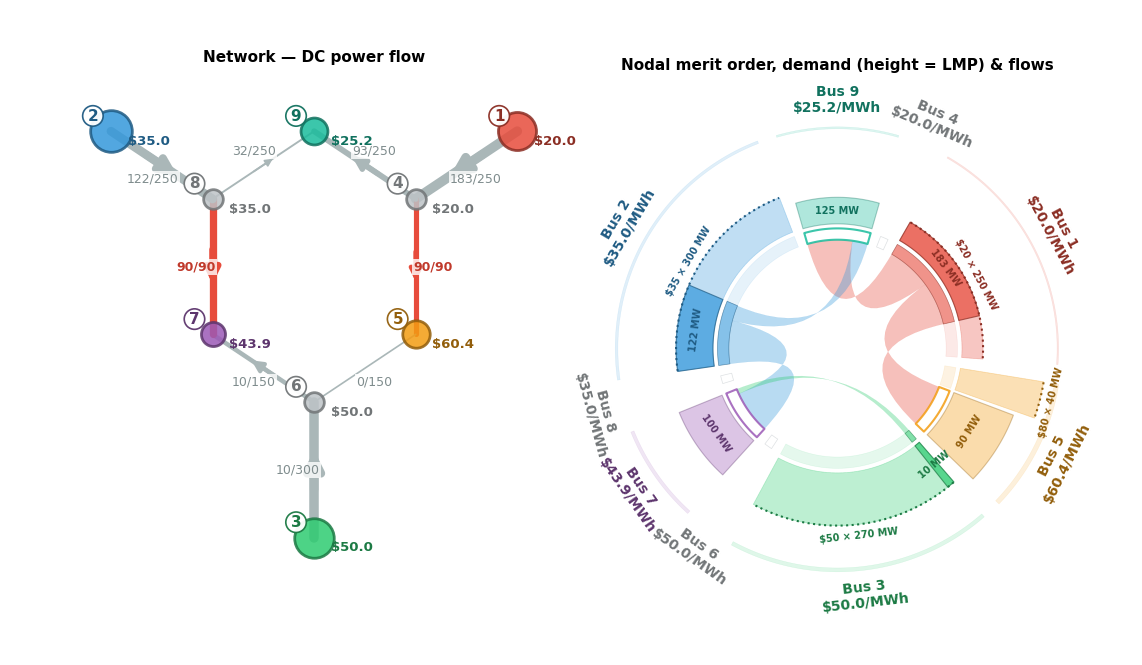

wrote seams_combined_figure.png (300 dpi) and seams_combined_figure.pdf to C:\Users\docke\Projects\ASSUME\assume\testbed

In [8]:
from nodal_plot import plot_combined_letter

binding_lines = {l for l, mu in res.line_dual.items() if abs(mu) > 1e-3}
fig, (ax_net, ax_circ) = plot_combined_letter(
    net, sup, dem,
    bus_colors=colors, bus_lmps=res.lmp,
    line_flows={l: res.flow_own[l] for l in pt.lines},
    line_widths=susceptance_widths(pt), constrained_lines=binding_lines,
    flows=nodal_plot.compute_ptdf_flows(net, sup, dem),
    clearing_price=res.energy_price,
    gen_marginal_costs={g: s['cost'] for g, s in unified.gens.items()},
    all_buses=pt.buses, sector_order=RING_ORDER,
    bus_coords=COORDS, center_bus=CENTER_BUS,   # rotated node diagram + bus 9 at 12 o'clock
)
fig.savefig('seams_combined_figure.png', dpi=300, bbox_inches='tight')
fig.savefig('seams_combined_figure.pdf', bbox_inches='tight')   # vector, for Word
plt.show()
print(f'wrote seams_combined_figure.png (300 dpi) and seams_combined_figure.pdf to {os.getcwd()}')

**Read it:** with `line_1` (4–5) and `line_5` (7–8) at 90 MW, the binding
constraints split the LMPs — the load pocket behind the constraint prices well
above the \$20 baseload bus. The congestion term is exactly
$\sum_m SF_{n,m}\,\mu_m$ (eq. 9); set `LINE_RATINGS = {}` and re-run to collapse
every bus back to a single energy price.

## 3. Two balancing authorities on the shared network

The same 9-bus nodal network, now read as **two balancing authorities** that
co-optimise a single dispatch but settle separately. The partition is an
*accounting overlay* on the unified clearing of Section 2 — the physics and the
LMPs are unchanged; the new question is **where the congestion revenue lands**.

- **BA-1** = buses {2, 8, 7, 6, 3} — the expensive fleet (gen_0 \$35 @ bus 2,
  gen_1 \$50 @ bus 3) and load at bus 7.
- **BA-2** = buses {1, 9, 4, 5} — the cheap baseload (gen_slack_0 \$20 @ bus 1),
  an \$80 pocket peaker at bus 5, and loads at buses 5 and 9.

This partition leaves **exactly two tie lines** (interconnectors) between the
BAs: `line_2` (5-6) and `line_7` (8-9). Every other line is internal to one BA.
BA-2 (cheap) tends to export across the seam to BA-1 (expensive).

In [9]:
# â”€â”€ Part 3 config: the two balancing authorities â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
BA_DEFS = {
    'BA-1': ['2', '8', '7', '6', '3'],   # expensive gens (bus 2 $35, bus 3 $50); load at 7
    'BA-2': ['1', '9', '4', '5'],         # cheap baseload (bus 1 $20) + $80 pocket peaker (bus 5); loads at 5 and 9
}
BA_COLORS = {'BA-1': '#C0392B', 'BA-2': '#2471A3'}

bus_to_ba = {str(b): ba for ba, buses in BA_DEFS.items() for b in buses}
ba_of = lambda b: bus_to_ba[str(b)]
LOADS_ALL = dict(LOADS)   # {'5': 90, '7': 100, '9': 125}

def line_kind(pt, l):
    # ('internal', ba) if both ends share a BA, else ('tie', None)
    i = pt.line_idx[l]; b0, b1 = pt.line_buses[i]
    return ('internal', ba_of(b0)) if ba_of(b0) == ba_of(b1) else ('tie', None)

pt = compute_ptdf(build_network(), slack_bus='1')
ties = [l for l in pt.lines if line_kind(pt, l)[0] == 'tie']

print('BA-1 buses:', BA_DEFS['BA-1'])
print('BA-2 buses:', BA_DEFS['BA-2'])
print('tie lines :', [f"{l} ({pt.line_buses[pt.line_idx[l]][0]}-{pt.line_buses[pt.line_idx[l]][1]})" for l in ties])
print('internal BA-1:', [l for l in pt.lines if line_kind(pt, l) == ('internal', 'BA-1')])
print('internal BA-2:', [l for l in pt.lines if line_kind(pt, l) == ('internal', 'BA-2')])

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


BA-1 buses:

['2', '8', '7', '6', '3']

BA-2 buses:

['1', '9', '4', '5']

...

['line_2 (5-6)', 'line_7 (8-9)']

internal BA-1:

['line_3', 'line_4', 'line_5', 'line_6']

internal BA-2:

['line_0', 'line_1', 'line_8']

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


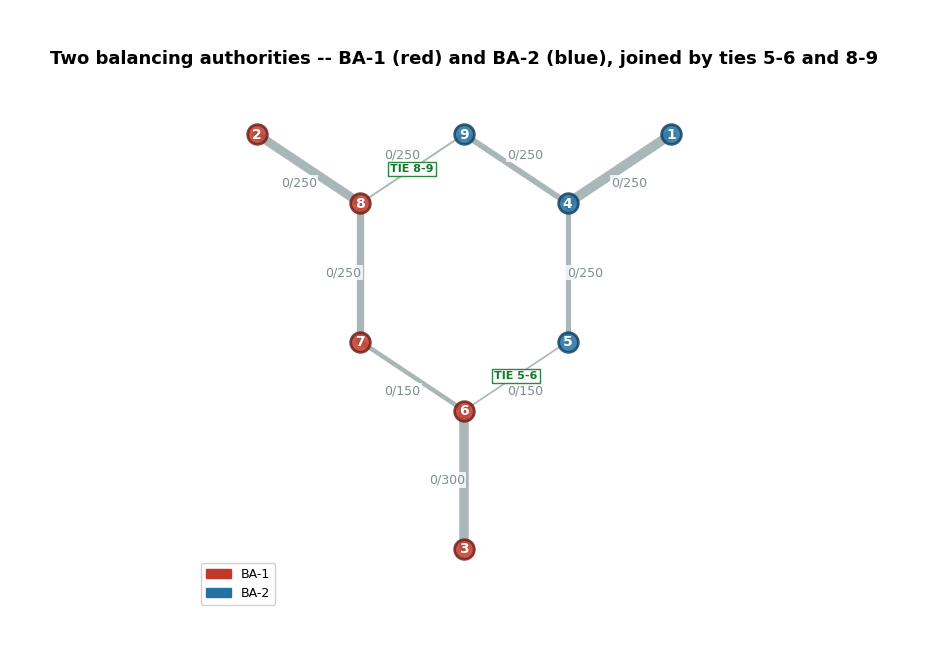

In [10]:
# Map of the two BAs and the interconnectors (buses coloured by BA).
ba_bus_colors = {b: BA_COLORS[ba_of(b)] for b in pt.buses}
fig, ax = plot_network_topology(
    build_network(), supply_by_bus={}, demand_by_bus={},
    bus_colors=ba_bus_colors, bus_coords=COORDS,
    line_flows={l: 0.0 for l in pt.lines}, line_widths=susceptance_widths(pt),
    title='Two balancing authorities -- BA-1 (red) and BA-2 (blue), joined by ties 5-6 and 8-9',
)
for l in ties:
    i = pt.line_idx[l]; b0, b1 = pt.line_buses[i]
    x0, y0 = COORDS[b0]; x1, y1 = COORDS[b1]
    ax.text((x0+x1)/2, (y0+y1)/2, f'TIE {b0}-{b1}', fontsize=8, fontweight='bold',
            color='#117A2B', ha='center', va='center',
            bbox=dict(fc='white', ec='#117A2B', alpha=0.9, pad=1.5), zorder=7)
import matplotlib.patches as mpatches
ax.legend(handles=[mpatches.Patch(color=BA_COLORS[ba], label=ba) for ba in BA_DEFS],
          loc='lower left', fontsize=9, framealpha=0.9)
plt.show()

### The dispatch, its Lagrangian, and where the congestion rent comes from

Everything in this section is read off **one** optimisation — the unified nodal
DC-OPF of Section&nbsp;2. We restate it compactly, take its Lagrangian, and show
that the congestion rent is a *by-product of the binding network constraints*. The
two allocation rules in the next cell are then just two ways of splitting that one
number between the BAs.

**The clearing (cost-minimising DC-OPF).** Generators $i$ with marginal cost
$c_i$ and capacity $\bar g_i$ at bus $\mathrm{bus}(i)$, against fixed load $d_n$ at
each bus $n$:

$$\min_{0\le g_i\le \bar g_i}\ \sum_i c_i\,g_i
  \qquad\text{s.t.}\qquad
  \sum_i g_i=\sum_n d_n\ \ [\lambda],
  \qquad
  -\bar F_l\le \textstyle\sum_n SF_{n,l}\,p^{\mathrm{inj}}_n\le \bar F_l\ \ [\mu_l],
  \quad l\in\mathcal M_{\mathrm{act}}. \qquad (1)$$

where the net injection at a bus is $p^{\mathrm{inj}}_n=\sum_{i:\,\mathrm{bus}(i)=n}g_i-d_n$
and the line flow $F_l=\sum_n SF_{n,l}\,p^{\mathrm{inj}}_n$ is built from the shared
shift factors of Section&nbsp;1.

*In words.* Dispatch the cheapest generation that meets total load without pushing any
monitored line past its rating. $\lambda$ is the multiplier on the energy balance; $\mu_l$
is the multiplier on line $l$'s limit — non-zero **only** when that line is full.

**The Lagrangian.**

$$\mathcal L=\sum_i c_i\,g_i\;-\;\lambda\!\left(\sum_i g_i-\sum_n d_n\right)
  \;-\;\sum_{l\in\mathcal M_{\mathrm{act}}}\mu_l\,F_l\;+\;(\text{generation-bound terms}). \qquad (2)$$

*In words.* Cost, minus the energy-balance multiplier times the energy imbalance, minus each
line's (signed) congestion multiplier times the flow on it. These shadow prices $\lambda,\mu_l$
are exactly what the solver returns (`res.energy_price`, `res.line_dual`).

**The price at every bus (paper eq.&nbsp;9).** Differentiating $\mathcal L$ with
respect to an injection at bus $n$ gives the locational marginal price

$$\lambda_n=\lambda+\sum_{l\in\mathcal M_{\mathrm{act}}}SF_{n,l}\,\mu_l. \qquad (3)$$

*In words.* A bus's price is the system energy price plus, for every binding line, that line's
shadow price scaled by the bus's shift factor onto the line. With nothing binding every bus
collapses to the one energy price $\lambda$; **a binding line is what pulls prices apart.**

**Where the rent comes from.** Value each binding line's limit at its shadow
price — equivalently, net the bus-level payments:

$$R=\sum_{l\in\mathcal M_{\mathrm{act}}}|\mu_l|\,|F_l|
   =\underbrace{\sum_n\lambda_n d_n}_{\text{paid by load}}
   -\underbrace{\sum_n\lambda_n g_n}_{\text{paid to generation}}. \qquad (4)$$

*In words.* The congestion rent (merchandising surplus) is the shadow price of each binding
line times the power on it — and it equals exactly what load pays minus what generation is
paid, because the energy components net to zero (total generation $=$ total load). **No
binding line $\Rightarrow$ no price separation $\Rightarrow R=0$.** This single number $R$ is
what the two methodologies below divide between the BAs.

### The ledger and the two allocation rules

The same rent $R$ from eq.&nbsp;(4), now split between the two BAs. First the per-BA
ledger, then the seam term, then the two methods — each as an equation with a
plain-language reading.

**Per-BA ledger.** For BA $a$ with buses $\mathcal N_a$:

$$G_a=\sum_{n\in\mathcal N_a}\lambda_n g_n,\qquad
  L_a=\sum_{n\in\mathcal N_a}\lambda_n d_n,\qquad
  N_a=L_a-G_a,\qquad \sum_a N_a=R. \qquad (5)$$

*In words.* $G_a$ is what the BA's **generators are paid**, $L_a$ what its **loads pay**, and
$N_a$ its **net payment into the congestion pool**. The two BAs' net payments sum to the whole
rent $R$ — congestion is a transfer from net-paying areas to net-receiving ones.
(`ba_settlement`: `gen_rev`, `load_pay`, `net_into_pool`.)

**Rent by line ownership.** Tag each binding line internal-to-a-BA or a tie:

$$R=R^{\mathrm{tie}}+\sum_a R^{\mathrm{int}}_a,\qquad
  R^{\mathrm{int}}_a=\!\!\sum_{l\,\in\,\mathrm{int}(a)}\!\!|\mu_l F_l|,\qquad
  R^{\mathrm{tie}}=\!\!\sum_{l\,\in\,\mathrm{ties}}\!\!|\mu_l F_l|. \qquad (6)$$

*In words.* Split the total rent by **which BA the binding line sits in**. A line wholly inside
BA $a$ feeds $R^{\mathrm{int}}_a$; the interconnectors feed $R^{\mathrm{tie}}$. (`line_rent_table`.)

**Cross-seam separation rent.** On each tie $l$ from $b_0$ to $b_1$ carrying flow
$F_l$, with $\Delta\lambda_l=\lambda_{b_1}-\lambda_{b_0}$:

$$\tau=\sum_{l\,\in\,\mathrm{ties}}\big|\,\Delta\lambda_l\,F_l\,\big|. \qquad (7)$$

*In words.* The price gap **across** the seam times the power crossing it — what the importing
BA's load pays *above* what the exporting BA's generation receives, just for the energy that
crosses. This is the piece of the rent the seam itself creates, and the piece Method&nbsp;2
reassigns. (`seam_separation`: `sep_rent`.)

---

**Method&nbsp;1 — the constraint's home BA keeps its full rent.**

$$A^{(1)}_a=R^{\mathrm{int}}_a+\tfrac12\,R^{\mathrm{tie}}. \qquad (8)$$

*In words.* Each BA banks the **full** $\mu_l\!\cdot\!F_l$ rent of every line it physically
contains; the shared ties are split 50/50. An **internal** constraint's rent stays home **even
when that constraint separated prices in the other BA** — the rent follows the wire, not the
price impact. This is the full constraint revenue accruing only to the home BA's settlement.

**Method&nbsp;2 — rebate the cross-seam separation to the load that over-paid.**
Let $h=\operatorname*{arg\,max}_a N_a$ be the **net-payer** BA and $f$ the other:

$$A^{(2)}_h=A^{(1)}_h+\tau,\qquad A^{(2)}_f=A^{(1)}_f-\tau. \qquad (9)$$

*In words.* Start from Method&nbsp;1, then **move the seam rent $\tau$** from the funding BA $f$
to the net-payer BA $h$ — the side whose loads over-paid because the constraint pulled their
price away from the generation serving them. This rebates the cross-seam
generation$\to$load transfer to that BA (congestion-revenue rights to its consumers). Total
rent is conserved: $A^{(2)}$ still sums to $R$. The choice of $\tau$ and of the recipient is a
**v1 rule, written explicitly so it can be refined** (e.g. later split $\tau$ between
importer-load and exporter-gen).

---

**Two readings of each BA's outcome** (the homework's columns, built in `revenue_table`):

$$\underbrace{P^{(k)}_a=A^{(k)}_a-N_a}_{\text{area net position}},
  \qquad\qquad
  \underbrace{\tilde L^{(k)}_a=L_a-A^{(k)}_a}_{\text{load cost net of CRR}}. \qquad (10)$$

*In words.* $P^{(k)}_a=0$ means method $k$ makes BA $a$ **whole** — its allocated rent exactly
offsets its net payment into the pool. $\tilde L^{(k)}_a$ is the BA's load bill **after** its
allocated rent is rebated to its own consumers as congestion-revenue rights — the number a
load-serving entity ultimately feels. Comparing these two columns across Method&nbsp;1 and
Method&nbsp;2 is the whole point of the exercise.

In [11]:
# â”€â”€ Methodology functions (edit these to refine the allocation rule) â”€â”€â”€â”€â”€â”€
def ba_settlement(res, loads):
    """Per-BA generator revenue (lmp*g) and load payment (lmp*d) at nodal LMPs."""
    out = {}
    for ba in BA_DEFS:
        buses = [b for b in res.lmp if ba_of(b) == ba]
        gen_rev = sum(res.lmp[b] * res.gen_by_bus.get(b, 0.0) for b in buses)
        load_pay = sum(res.lmp[b] * float(loads.get(b, 0.0)) for b in buses)
        out[ba] = dict(gen_rev=gen_rev, load_pay=load_pay, net_into_pool=load_pay - gen_rev)
    return out

def line_rent_table(res, pt):
    """Per-line congestion rent |mu|*|flow|, tagged internal/tie and home BA."""
    recs = []
    for l in pt.lines:
        i = pt.line_idx[l]; b0, b1 = pt.line_buses[i]
        kind, home = line_kind(pt, l)
        mu, F = res.line_dual[l], res.flow_own[l]
        recs.append(dict(line=l, frm=b0, to=b1, kind=kind, home=home,
                         mu=round(mu, 2), flow=round(F, 1), rent=abs(mu) * abs(F)))
    return pd.DataFrame(recs).set_index('line')

def seam_separation(res, pt):
    """Cross-seam price-separation rent per tie: |(lmp_to-lmp_from)*flow|, and
    which BA imports (the higher-priced end the power flows into)."""
    recs = []
    for l in ties:
        i = pt.line_idx[l]; b0, b1 = pt.line_buses[i]
        F, dlam = res.flow_own[l], res.lmp[b1] - res.lmp[b0]
        imp = ba_of(b1) if F >= 0 else ba_of(b0)
        exp = ba_of(b0) if F >= 0 else ba_of(b1)
        recs.append(dict(line=l, flow=round(F, 1), dlam=round(dlam, 2),
                         sep_rent=abs(dlam * F), importing=imp, exporting=exp))
    return pd.DataFrame(recs).set_index('line')

def allocate_congestion_rent(res, pt, loads, tie_split=0.5):
    """Allocate total congestion rent to the two BAs under both methodologies."""
    lr, sep = line_rent_table(res, pt), seam_separation(res, pt)
    R = lr['rent'].sum()
    R_tie = lr[lr.kind == 'tie']['rent'].sum()
    R_int = {ba: lr[(lr.kind == 'internal') & (lr.home == ba)]['rent'].sum() for ba in BA_DEFS}
    R_seam = sep['sep_rent'].sum() if len(sep) else 0.0
    # The BA to HEDGE is the net payer into the congestion pool (load_pay - gen_rev
    # largest): its participants over-paid because of the price separation. Method 2
    # rebates the cross-seam separation rent tau to it, funded by the other BA.
    settle = ba_settlement(res, loads)
    hedged_ba = max(BA_DEFS, key=lambda ba: settle[ba]['net_into_pool'])
    funding_ba = [ba for ba in BA_DEFS if ba != hedged_ba][0]

    alloc = {ba: dict(R_int=R_int[ba], tie_share=tie_split * R_tie,
                      method1=R_int[ba] + tie_split * R_tie) for ba in BA_DEFS}
    tau = R_seam   # Method 2: move cross-seam separation rent funding_ba -> hedged_ba
    alloc[hedged_ba]['method2'] = alloc[hedged_ba]['method1'] + tau
    alloc[funding_ba]['method2'] = alloc[funding_ba]['method1'] - tau
    summary = dict(R=R, R_tie=R_tie, R_int=R_int, R_seam=R_seam,
                   hedged_ba=hedged_ba, funding_ba=funding_ba, tau=tau)
    return pd.DataFrame(alloc).T[['R_int', 'tie_share', 'method1', 'method2']], summary, lr, sep

def compare_methods(res, pt, loads):
    """Tidy side-by-side BA settlement + Method 1 / Method 2 allocation table."""
    alloc, summ, lr, sep = allocate_congestion_rent(res, pt, loads)
    settle = ba_settlement(res, loads)
    tbl = pd.DataFrame({ba: {
        'generator revenue (lmp*g)': settle[ba]['gen_rev'],
        'load payment (lmp*d)': settle[ba]['load_pay'],
        'internal-line rent': alloc.loc[ba, 'R_int'],
        'tie-rent share': alloc.loc[ba, 'tie_share'],
        'congestion rent -- Method 1': alloc.loc[ba, 'method1'],
        'congestion rent -- Method 2': alloc.loc[ba, 'method2'],
    } for ba in BA_DEFS})
    tbl['TOTAL'] = tbl.sum(axis=1)
    return tbl.round(1), summ, lr, sep

print('methodology loaded: ba_settlement, line_rent_table, seam_separation, '
      'allocate_congestion_rent, compare_methods')

methodology loaded: ba_settlement, line_rent_table, seam_separation, allocate_congestion_rent, compare_methods

In [12]:
# â”€â”€ Presentation helpers: per-example composite figure + homework-style table â”€
def example_figure(net, pt, engine, res, *, dim_buses=None, suptitle=None,
                   title_left='Network -- DC power flow',
                   title_right='Nodal merit order, demand (height = LMP) & flows'):
    """Combined network + nodal-merit (circlize) composite for one clearing.
    dim_buses: buses to grey out (e.g. the other BA in a per-BA view)."""
    sup, dem = to_supply_demand(engine, res)
    colors = dict(BUS_COLORS)   # canonical colours; a subset clearing no longer reshuffles them
    for b in (dim_buses or []):
        colors[str(b)] = '#C8CCCE'   # grey out the other BA
    binding = {l for l, mu in res.line_dual.items() if abs(mu) > 1e-3}
    fig, _ = plot_combined_letter(
        net, sup, dem,
        bus_colors=colors, bus_lmps=res.lmp,
        line_flows={l: res.flow_own[l] for l in pt.lines},
        line_widths=susceptance_widths(pt), constrained_lines=binding,
        flows=nodal_plot.compute_ptdf_flows(net, sup, dem),
        clearing_price=res.energy_price,
        gen_marginal_costs={g: s['cost'] for g, s in engine.gens.items()},
        all_buses=pt.buses, sector_order=RING_ORDER,
        bus_coords=COORDS, center_bus=CENTER_BUS,
        title_left=title_left, title_right=title_right, suptitle=suptitle,
    )
    return fig

def revenue_table(res, pt, loads):
    """Homework-style congestion-revenue table: how each BA's LOAD and AREA fare
    under Method 1 vs Method 2. Total rent is conserved; the transfer row is M2-M1.

    - 'Area net position' = rent received - net paid into the pool (0 => whole).
    - 'Load cost net of CRR' = load payment - rent, i.e. the bill if the BA's
      congestion rent is rebated to its own consumers (congestion-revenue rights)."""
    alloc, summ, lr, sep = allocate_congestion_rent(res, pt, loads)
    s = ba_settlement(res, loads)
    rows = {}
    for ba in BA_DEFS:
        gr, lp = s[ba]['gen_rev'], s[ba]['load_pay']
        m1, m2 = alloc.loc[ba, 'method1'], alloc.loc[ba, 'method2']
        net_in = lp - gr
        rows[ba] = {
            'Load payment  (lmp*d)': lp,
            'Generator revenue  (lmp*g)': gr,
            'Net paid into congestion pool': net_in,
            'Congestion rent -- Method 1': m1,
            'Congestion rent -- Method 2': m2,
            'Area net position -- Method 1': m1 - net_in,
            'Area net position -- Method 2': m2 - net_in,
            'Transfer (Method 2 - Method 1)': m2 - m1,
            'Load cost net of CRR -- Method 1': lp - m1,
            'Load cost net of CRR -- Method 2': lp - m2,
        }
    tbl = pd.DataFrame(rows)
    tbl['TOTAL'] = tbl.sum(axis=1)
    return tbl.round(1), summ

print('presentation helpers loaded: example_figure, revenue_table')

presentation helpers loaded: example_figure, revenue_table

### Scenario 3A — a tie (interconnector) is the binding constraint

The simplest case: squeeze a tie line so the **interconnector itself** congests.
The rent is collected directly on the seam, both BAs sit at the two ends of the
binding line, and the two allocation methods nearly coincide (the rent *is* the
cross-seam separation). Edit `SCN_A` to move the squeeze.

In [13]:
# -- EDIT -- Scenario A: congest a tie line directly
SCN_A = {'line_2': 15.0}          # tighten the 5-6 interconnector below its ~27 MW natural flow
# -------------------------------------------------------------------------
net = build_network(SCN_A); pt = compute_ptdf(net, slack_bus='1')
res = solve_engine_dispatch(pt, make_engine('UNIFIED', buses=pt.buses))

print('LMP by bus:', {b: round(res.lmp[b], 1) for b in pt.buses})
print('binding lines:', {l: round(res.line_dual[l], 1) for l in pt.lines if abs(res.line_dual[l]) > 1e-3},
      '(kind:', {l: line_kind(pt, l) for l in pt.lines if abs(res.line_dual[l]) > 1e-3}, ')')

tbl, summ, lr, sep = compare_methods(res, pt, LOADS_ALL)
print('\nper-line congestion rent (binding lines):')
display(lr[lr.rent > 1e-3].round({'rent': 1}))
print('cross-seam separation by tie:')
display(sep.round({'sep_rent': 1}))
print(f"total rent R = {summ['R']:.1f}  |  on ties = {summ['R_tie']:.1f}  |  "
      f"cross-seam separation tau = {summ['tau']:.1f}  |  net-payer (hedged) BA = {summ['hedged_ba']}")
print('\nBA settlement and rent allocation ($/h):')
display(tbl)

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


LMP by bus:

{'1': np.float64(20.0), '2': np.float64(35.0), '3': np.float64(45.5), '4': np.float64(20.0), '5': np.float64(14.4), '6': np.float64(45.5), '7': np.float64(39.4), '8': np.float64(35.0), '9': np.float64(25.2)}

binding lines:

{'line_2': -41.5}

...

cross-seam separation by tie:

,flow,dlam,sep_rent,importing,exporting
line,,,,,
line_2,15.0,31.15,467.2,BA-1,BA-2
line_7,12.3,-9.82,120.6,BA-2,BA-1


total rent R = 622.7  |  on ties = 622.7  |  cross-seam separation tau = 587.8  |  net-payer (hedged) BA = BA-1


BA settlement and rent allocation ($/h):

,BA-1,BA-2,TOTAL
generator revenue (lmp*g),3405.1,4354.2,7759.3
load payment (lmp*d),3939.0,4443.0,8382.0
internal-line rent,0.0,0.0,0.0
tie-rent share,311.3,311.3,622.7
congestion rent -- Method 1,311.3,311.3,622.7
congestion rent -- Method 2,899.2,-276.5,622.7


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


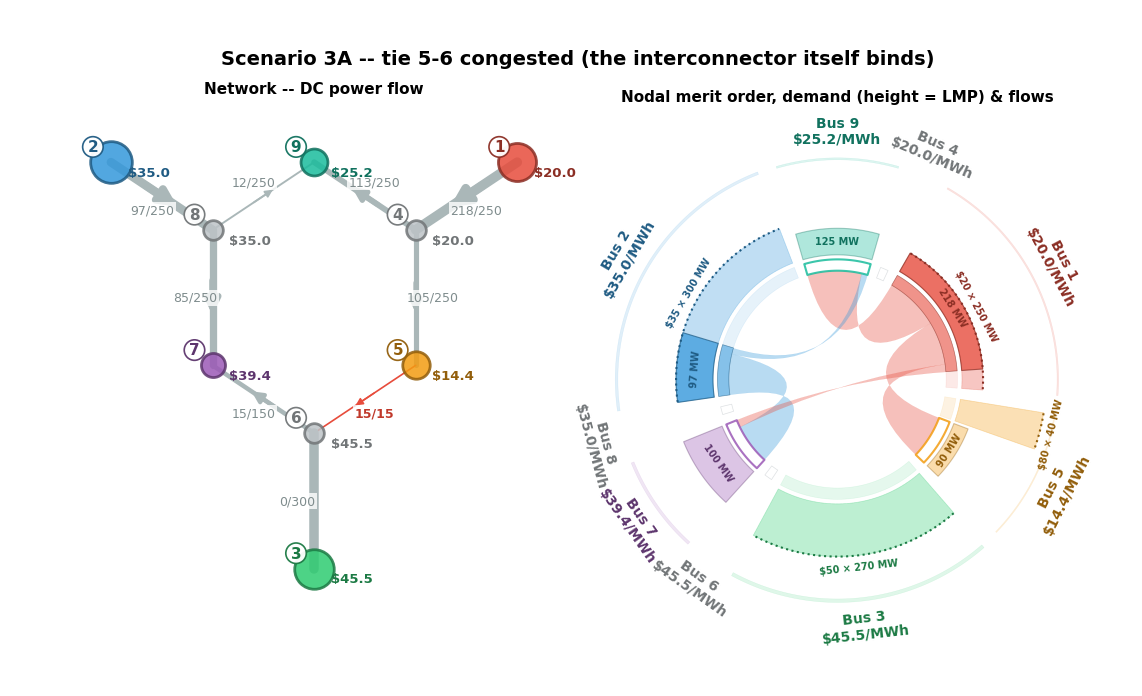

Scenario 3A: rent collected on the tie, R = $623/h; Method 2 hedges the net-payer BA-1 with tau = $588/h.

,BA-1,BA-2,TOTAL
Load payment (lmp*d),3939.0,4443.0,8382.0
Generator revenue (lmp*g),3405.1,4354.2,7759.3
Net paid into congestion pool,533.9,88.8,622.7
Congestion rent -- Method 1,311.3,311.3,622.7
Congestion rent -- Method 2,899.2,-276.5,622.7
Area net position -- Method 1,-222.6,222.6,-0.0
Area net position -- Method 2,365.3,-365.3,-0.0
Transfer (Method 2 - Method 1),587.8,-587.8,-0.0
Load cost net of CRR -- Method 1,3627.7,4131.6,7759.3
Load cost net of CRR -- Method 2,3039.8,4719.5,7759.3


In [14]:
# Scenario 3A -- composite figure + homework-style congestion-revenue table.
net = build_network(SCN_A); pt = compute_ptdf(net, slack_bus='1')
uni = make_engine('UNIFIED', buses=pt.buses); res = solve_engine_dispatch(pt, uni)
example_figure(net, pt, uni, res,
               suptitle='Scenario 3A -- tie 5-6 congested (the interconnector itself binds)')
plt.show()
rtbl, summ = revenue_table(res, pt, LOADS_ALL)
print(f"Scenario 3A: rent collected on the tie, R = ${summ['R']:.0f}/h; Method 2 hedges "
      f"the net-payer {summ['hedged_ba']} with tau = ${summ['tau']:.0f}/h.")
display(rtbl)

### Scenario 3B — an *internal* constraint, separation in the *other* BA

The interesting case for congestion-revenue allocation. We congest a line that
lives **entirely inside BA-2**. The binding limit both isolates a price pocket at
the BA-2 load behind it **and**, through the shift factors, pulls **BA-1's prices
away from the system price** as BA-1 generation is redispatched across the seam —
so **prices separate on both sides even though the binding line is internal to
BA-2 and no tie is overloaded.**

- **Method 1** credits all of the rent to **BA-2** (it physically owns the
  binding line), regardless of where the price separation is felt.
- **Method 2** rebates the cross-seam separation rent $\tau$ to whichever BA is
  the **net payer** into the congestion pool — the side whose load over-paid for
  the separation — funded by the other BA.

Whether the net-payer turns out to be BA-1 or BA-2 depends on the squeeze; the
cells below report it from the actual settlement rather than assuming it. Edit
`SCN_B` to choose which internal BA-2 line binds and how hard.

In [15]:
# -- EDIT -- Scenario B: congest a line INTERNAL to BA-2 (the exporter)
SCN_B = {'line_1': 70.0}          # 4-5, internal to BA-2; throttles cheap export
# -------------------------------------------------------------------------
net = build_network(SCN_B); pt = compute_ptdf(net, slack_bus='1')
res = solve_engine_dispatch(pt, make_engine('UNIFIED', buses=pt.buses))

print('LMP by bus:', {b: round(res.lmp[b], 1) for b in pt.buses})
print('  BA-1 LMPs:', {b: round(res.lmp[b], 1) for b in BA_DEFS['BA-1']})
print('  BA-2 LMPs:', {b: round(res.lmp[b], 1) for b in BA_DEFS['BA-2']})
print('binding lines:', {l: round(res.line_dual[l], 1) for l in pt.lines if abs(res.line_dual[l]) > 1e-3},
      '(kind:', {l: line_kind(pt, l) for l in pt.lines if abs(res.line_dual[l]) > 1e-3}, ')')

tbl, summ, lr, sep = compare_methods(res, pt, LOADS_ALL)
print('\nper-line congestion rent (binding lines):')
display(lr[lr.rent > 1e-3].round({'rent': 1}))
print('cross-seam separation by tie  (note: a tie carries separation even though it does NOT bind):')
display(sep.round({'sep_rent': 1}))
print(f"total rent R = {summ['R']:.1f}  |  internal BA-2 = {summ['R_int']['BA-2']:.1f}  |  "
      f"internal BA-1 = {summ['R_int']['BA-1']:.1f}  |  on ties = {summ['R_tie']:.1f}")
print(f"cross-seam separation tau = {summ['tau']:.1f}  ->  net-payer (hedged) BA = {summ['hedged_ba']} "
      f"(Method 2 moves tau from {summ['funding_ba']} to {summ['hedged_ba']})")
print('\nBA settlement and rent allocation ($/h):')
display(tbl)

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


LMP by bus:

{'1': np.float64(20.0), '2': np.float64(35.0), '3': np.float64(45.5), '4': np.float64(20.0), '5': np.float64(55.9), '6': np.float64(45.5), '7': np.float64(39.4), '8': np.float64(35.0), '9': np.float64(25.2)}

  BA-1 LMPs:

{'2': np.float64(35.0), '8': np.float64(35.0), '7': np.float64(39.4), '6': np.float64(45.5), '3': np.float64(45.5)}

...

,flow,dlam,sep_rent,importing,exporting
line,,,,,
line_2,-20.0,-10.37,207.3,BA-2,BA-1
line_7,74.2,-9.82,727.9,BA-2,BA-1


total rent R = 2905.9  |  internal BA-2 = 2905.9  |  internal BA-1 = 0.0  |  on ties = 0.0

cross-seam separation tau = 935.3  ->  net-payer (hedged) BA = BA-2 (Method 2 moves tau from BA-1 to BA-2)


BA settlement and rent allocation ($/h):

,BA-1,BA-2,TOTAL
generator revenue (lmp*g),6795.3,2417.0,9212.3
load payment (lmp*d),3939.0,8179.1,12118.1
internal-line rent,0.0,2905.9,2905.9
tie-rent share,0.0,0.0,0.0
congestion rent -- Method 1,0.0,2905.9,2905.9
congestion rent -- Method 2,-935.3,3841.1,2905.9


**Reading Scenario 3B.** The binding constraint is inside BA-2, so under
**Method 1** BA-2 banks the entire congestion rent simply because its wires host
the limit. **Method 2** instead rebates the cross-seam separation $\tau$ to the
BA whose participants were the net payers for that separation, so each BA ends up
holding rent commensurate with the price gap *its own meters* bore rather than the
gap its wires happened to host. The `TOTAL` column is identical under both methods
— the rent is only **reallocated**, never created or destroyed. (The contrast is
sharpest when the constraint's home BA and the net-paying BA differ; tune `SCN_B`
to explore that.)

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


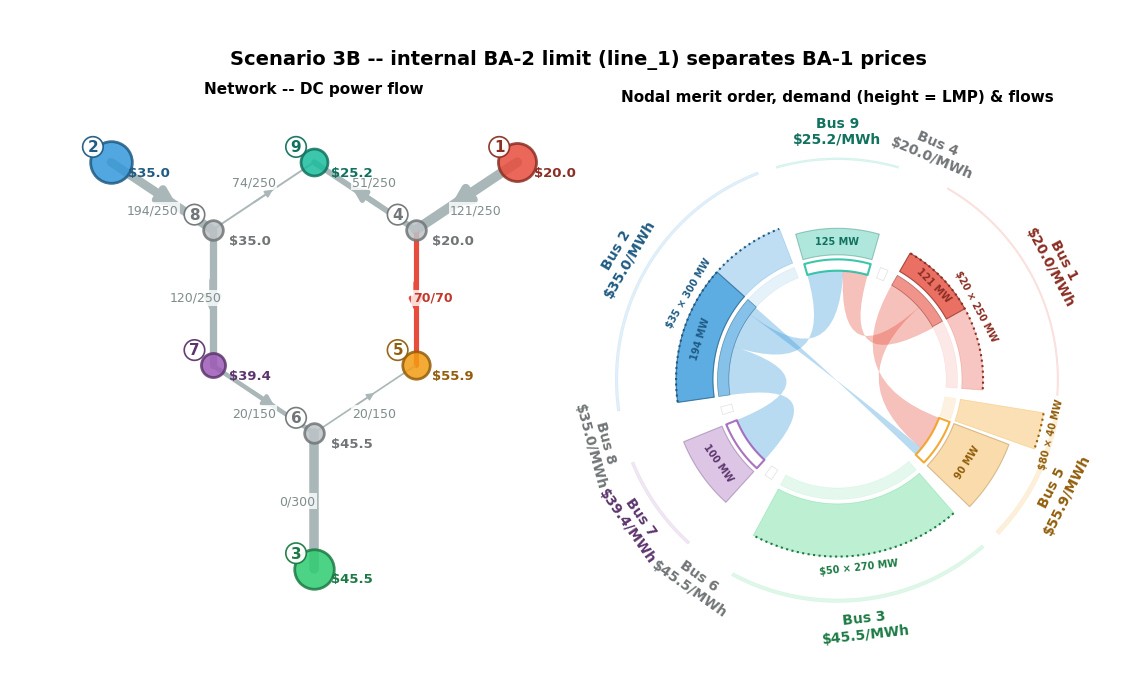

Scenario 3B: internal BA-2 rent R = $2906/h; Method 1 banks it all in BA-2, Method 2 moves tau = $935/h to net-payer BA-2.

Read the table: the Area-net-position rows show Method 2 shrinking the cross-seam imbalance; the Load-cost-net-of-CRR rows show how the consumers in each BA fare if the rent is rebated to them.

,BA-1,BA-2,TOTAL
Load payment (lmp*d),3939.0,8179.1,12118.1
Generator revenue (lmp*g),6795.3,2417.0,9212.3
Net paid into congestion pool,-2856.2,5762.1,2905.9
Congestion rent -- Method 1,0.0,2905.9,2905.9
Congestion rent -- Method 2,-935.3,3841.1,2905.9
Area net position -- Method 1,2856.2,-2856.2,-0.0
Area net position -- Method 2,1921.0,-1921.0,-0.0
Transfer (Method 2 - Method 1),-935.3,935.3,0.0
Load cost net of CRR -- Method 1,3939.0,5273.2,9212.3
Load cost net of CRR -- Method 2,4874.3,4338.0,9212.3


In [16]:
# Scenario 3B -- composite figure + homework-style congestion-revenue table.
net = build_network(SCN_B); pt = compute_ptdf(net, slack_bus='1')
uni = make_engine('UNIFIED', buses=pt.buses); res = solve_engine_dispatch(pt, uni)
example_figure(net, pt, uni, res,
               suptitle='Scenario 3B -- internal BA-2 limit (line_1) separates BA-1 prices')
plt.show()
rtbl, summ = revenue_table(res, pt, LOADS_ALL)
print(f"Scenario 3B: internal BA-2 rent R = ${summ['R']:.0f}/h; Method 1 banks it all in "
      f"BA-2, Method 2 moves tau = ${summ['tau']:.0f}/h to net-payer {summ['hedged_ba']}.")
print('Read the table: the Area-net-position rows show Method 2 shrinking the cross-seam '
      'imbalance; the Load-cost-net-of-CRR rows show how the consumers in each BA fare if '
      'the rent is rebated to them.')
display(rtbl)

### Unified vs independent operation — the two-engine counterfactual

The cross-seam separation exists only because a **single co-optimised clearing**
prices every bus against *all* constraints at once. The counterfactual is
**independent operation**: each BA runs as its own *seams-style engine* on the
same full 9-bus network — serving its own load from its own generators and
enforcing **only its own internal lines**, with everything outside the BA left
unconstrained (a nodal DC-OPF per BA, not a copperplate). No interchange is
scheduled.

Two things surface:

1. On the **base network** each BA clears at its own price (BA-1 \$35, BA-2 \$20);
   that gap is exactly what trade across the seam captures.
2. On the **Scenario-B network**, BA-2 clears **feasibly only by running its own
   \$80 pocket peaker** at bus 5 — the load trapped behind the `line_1` limit can
   no longer reach the cheap bus-1 generation, so bus 5 prices all the way up to
   \$80 under independent operation. Under the **unified clearing**, imports across
   the seam relieve that pocket and bus 5 settles far lower (\$55.9). So
   coordination both *lowers* the pocket price **and** creates the cross-seam
   congestion rent that then has to be allocated — without it, BA-2 would lean on
   its most expensive unit and its consumers would pay the pocket price in full.

In [17]:
# Independent operation: each BA as its OWN seams-style engine on the full network
# -- own gens serve own load, enforcing ONLY its own internal lines (rest relaxed),
# no interchange. A nodal DC-OPF per BA; infeasibility is itself a finding.
def independent_clear(rat):
    n = build_network(rat); pt = compute_ptdf(n, slack_bus='1')
    out = {}
    for ba in BA_DEFS:
        act = [l for l in pt.lines if line_kind(pt, l) == ('internal', ba)]
        try:
            out[ba] = solve_engine_dispatch(pt, make_engine(ba, BA_DEFS[ba], activated=act))
        except RuntimeError:
            out[ba] = None
    return pt, out

# (a) Base network -- both BAs self-serve; the price gap is what motivates trade.
_, base = independent_clear({})
print('independent prices on the BASE network:',
      {ba: (f"${base[ba].energy_price:.0f}" if base[ba] else 'INFEASIBLE') for ba in BA_DEFS})

# (b) Scenario-B network -- the internal BA-2 limit as the counterfactual stress.
ptB, indep = independent_clear(SCN_B)
resU = solve_engine_dispatch(ptB, make_engine('UNIFIED', buses=ptB.buses))
cmp = pd.DataFrame({b: {
    'BA': ba_of(b),
    'independent LMP': (round(indep[ba_of(b)].lmp[b], 1) if indep[ba_of(b)] else float('nan')),
    'unified LMP (Scn B)': round(resU.lmp[b], 1),
} for b in ptB.buses}).T
display(cmp)
for ba in BA_DEFS:
    if indep[ba] is None:
        print(f'{ba} is INFEASIBLE on its own: with the line_1 limit and only its own '
              f'generation it cannot serve its load -- it depends on imports across the '
              f'seam. That dependence is what the unified clearing prices, and what the '
              f'congestion-revenue allocation then divides.')
    else:
        gap = max(indep[ba].lmp[b] for b in BA_DEFS[ba]) - min(indep[ba].lmp[b] for b in BA_DEFS[ba])
        print(f'{ba} independent: clears feasibly, internal price spread ${gap:.1f}/MWh.')

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


independent prices on the BASE network:

{'BA-1': '$35', 'BA-2': '$20'}

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


,BA,independent LMP,unified LMP (Scn B)
1,BA-2,20.0,20.0
2,BA-1,35.0,35.0
3,BA-1,35.0,45.5
4,BA-2,20.0,20.0
5,BA-2,80.0,55.9
6,BA-1,35.0,45.5
7,BA-1,35.0,39.4
8,BA-1,35.0,35.0
9,BA-2,28.7,25.2


BA-1 independent: clears feasibly, internal price spread $0.0/MWh.

BA-2 independent: clears feasibly, internal price spread $60.0/MWh.

### The two-BA dispatch, per BA (other BA greyed)

The independent two-BA dispatch drawn as a combined network + nodal-merit chart
**for each BA in turn**, with the other BA's nodes greyed out. Because each BA
clears only its own footprint, its chart shows only its own generation, load, and
within-BA chords — the greyed nodes mark the seam it does not see. Note BA-2's
bus-5 pocket peaker running at \$80 here, the price its consumers would pay without
the imports a coordinated clearing provides.

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


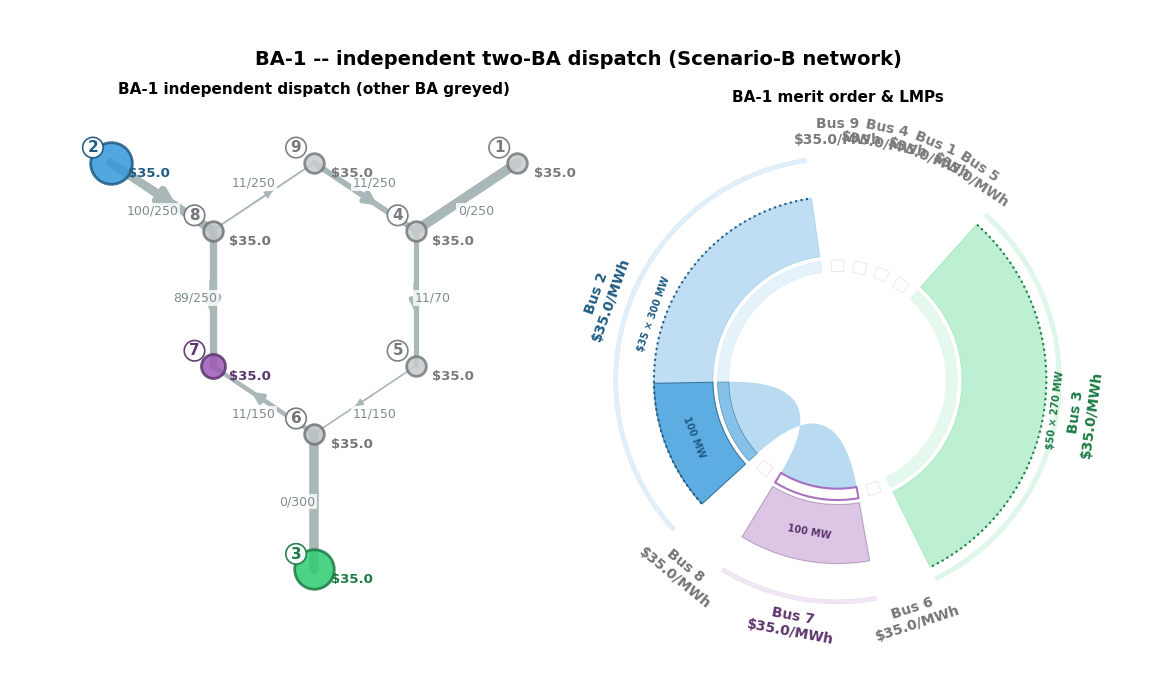

BA-1: energy $35/MWh; own-bus LMPs {'2': np.float64(35.0), '8': np.float64(35.0), '7': np.float64(35.0), '6': np.float64(35.0), '3': np.float64(35.0)}

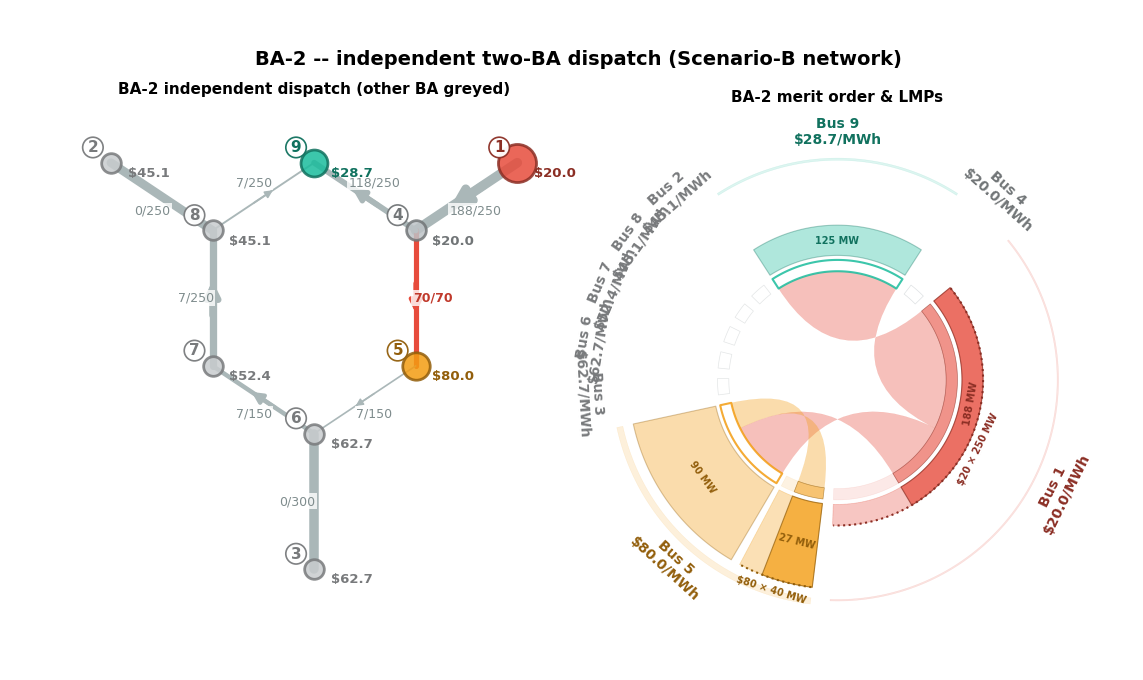

BA-2: energy $20/MWh; own-bus LMPs {'1': np.float64(20.0), '9': np.float64(28.7), '4': np.float64(20.0), '5': np.float64(80.0)}

In [18]:
# Per-BA composite of the INDEPENDENT two-BA dispatch (Scenario-B network),
# with the other BA's nodes greyed out. Each BA clears only its own footprint,
# so its chart carries only its own generation, load, and within-BA chords.
netB = build_network(SCN_B); ptB = compute_ptdf(netB, slack_bus='1')
for ba in BA_DEFS:
    act = [l for l in ptB.lines if line_kind(ptB, l) == ('internal', ba)]
    eng = make_engine(ba, BA_DEFS[ba], activated=act)
    r = solve_engine_dispatch(ptB, eng)
    other = [b for b in ptB.buses if ba_of(b) != ba]
    example_figure(netB, ptB, eng, r, dim_buses=other,
                   title_left=f'{ba} independent dispatch (other BA greyed)',
                   title_right=f'{ba} merit order & LMPs',
                   suptitle=f'{ba} -- independent two-BA dispatch (Scenario-B network)')
    plt.show()
    print(f"{ba}: energy ${r.energy_price:.0f}/MWh; own-bus LMPs "
          f"{ {b: round(r.lmp[b], 1) for b in BA_DEFS[ba]} }")

### Where this goes next

The scaffold above is the **methodology**: a unified nodal clearing, a
congestion-revenue ledger split by BA and tie, and the two allocation rules
(home-keeps-it vs rebate-cross-seam-separation) compared on both a tie-congested
and an internal-constraint case, alongside the unified-vs-separated contrast.

Planned refinements (to work through next):

1. **Two-part supply curves per BA** — a flat baseload block (the in-BA baseload
   unit) plus a smooth linear mid-merit/peaking ramp, replacing the discrete
   three-unit fleet so price separation varies continuously with the squeeze.
2. **Sweep the tie / internal limit** and trace how $\tau$ and each BA's net
   position move — the congestion-revenue analogue of the homework's $C_{tot}$ /
   $R_{tot}$ curves.
3. **Refine the Method-2 transfer rule** (e.g. split $\tau$ between importer load
   and exporter generation rather than a single directed transfer).